In [1]:
"""
Banka Musteri Kaybi (Churn) Tahmini - Uctan Uca Makine Ogrenmesi Projesi
=========================================================================

Amac
----
Bu proje, bir bankanin musteri veri tabanindaki bilgileri kullanarak bir
musterinin bankadan ayrilip ayrilmayacagini (churn) tahmin etmeyi
amaclamaktadir. Calisma; veri inceleme, veri on isleme, oznitelik
muhendisligi, model egitimi, model karsilastirma, capraz dogrulama,
hiperparametre ayarlama ve sonuc yorumlama adimlarini uctan uca kapsayan
bir siniflandirma (classification) projesidir.

Veri Seti
---------
Kaggle uzerinde Usability puani 10 olan "Churn_Modelling.csv" veri seti
kullanilmistir. Veri seti 10.000 musteriye ait demografik ve bankacilik
bilgilerini icermektedir. Hedef degisken "Exited" olup, musterinin
bankadan ayrilip ayrilmadigini (1/0) gosterir.

Kullanilan Kutuphaneler
------------------------
- pandas, numpy        : veri okuma ve manipulasyonu
- matplotlib, seaborn   : gorsellestirme
- scikit-learn          : on isleme, modelleme, model degerlendirme,
                          hiperparametre ayarlama

Calistirma Adimlari
--------------------
1. Bu notebook'un bulundugu klasorde 'Churn_Modelling.csv' dosyasinin
   mevcut oldugundan emin olun.
2. 'pip install -r requirements.txt' komutu ile gerekli kutuphaneleri kurun.
3. Hucreleri sirasiyla (yukaridan asagiya) calistirin.
"""

print("Banka Musteri Kaybi (Churn) Tahmini Projesi baslatiliyor...")


Banka Musteri Kaybi (Churn) Tahmini Projesi baslatiliyor...


In [2]:
# Gerekli kutuphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 2. Veri Setinin Okunmasi ve Problem Tanimi

Veri seti `pandas` ile okunmustur. **Churn_Modelling.csv** veri seti, bir bankanin
10.000 musterisine ait demografik (yas, cinsiyet, ulke) ve bankacilik (kredi
skoru, bakiye, urun sayisi, aktiflik durumu vb.) bilgilerini icerir.

**Cozulen Problem:** Bankanin, mevcut musterilerinden hangilerinin yakin
gelecekte bankadan ayrilacagini (churn/kayip) onceden tahmin etmesi
gerekmektedir. Bu sayede banka, ayrilma riski yuksek musterilere yonelik
elde tutma (retention) stratejileri gelistirebilir.


In [3]:
# Veri setinin pandas ile okunmasi
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Hedef Degisken ve Problem Turu

Hedef degisken (target): **`Exited`**

- `Exited = 1` -> Musteri bankadan ayrildi (churn)
- `Exited = 0` -> Musteri bankada kalmaya devam ediyor

Hedef degisken iki sinifli (0/1) oldugu icin bu problem bir
**siniflandirma (classification)** problemidir, regresyon degildir.


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


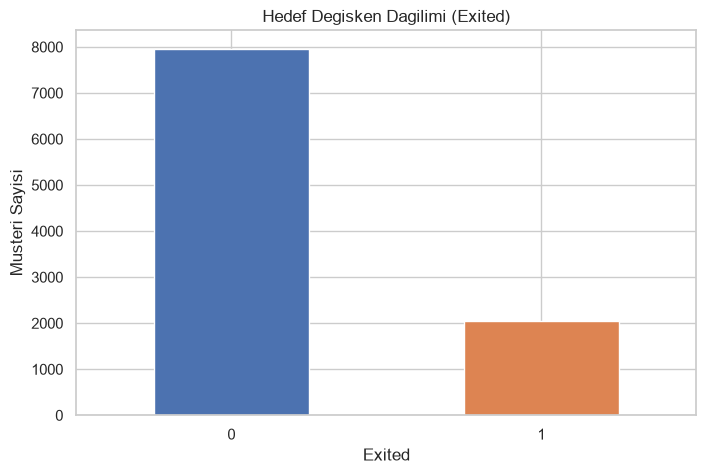

In [4]:
# Hedef degiskenin sinif dagilimi (dengesiz mi degil mi kontrolu)
target_col = "Exited"
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True).round(3))

df[target_col].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Hedef Degisken Dagilimi (Exited)")
plt.xlabel("Exited")
plt.ylabel("Musteri Sayisi")
plt.xticks(rotation=0)
plt.show()


## 4. Veri Setinin Genel Incelemesi

Bu bolumde veri setinin boyutu, sutun veri tipleri ve temel istatistiksel
ozetleri incelenmektedir.


In [5]:
# Satir ve sutun sayisi
print(f"Satir sayisi: {df.shape[0]}")
print(f"Sutun sayisi: {df.shape[1]}")


Satir sayisi: 10000
Sutun sayisi: 14


In [6]:
# Veri tipleri ve genel bilgi
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# Sayisal degiskenler icin temel istatistikler
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Kategorik degiskenler icin temel istatistikler
df.describe(include="object")


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


## 5. Eksik Deger Kontrolu

Bu asamada veri setindeki eksik (null) degerler kontrol edilmektedir. Eksik
deger bulunmasi durumunda uygun doldurma/temizleme stratejisi uygulanacaktir.


In [9]:
# Eksik deger kontrolu
print("Eksik deger sayilari:")
print(df.isnull().sum())

print("\nTekrarlanan (duplicate) satir sayisi:", df.duplicated().sum())
print("Tekrarlanan CustomerId sayisi:", df["CustomerId"].duplicated().sum())

# Not: Bu veri setinde eksik deger ve tekrarlanan satir bulunmamaktadir.
# Eksik deger olsaydi, sayisal degiskenler icin medyan/ortalama, kategorik
# degiskenler icin mod (en sik gorulen deger) ile doldurma (fillna) veya
# eksiklik orani cok yuksekse ilgili satir/sutunun silinmesi (dropna/drop)
# tercih edilebilirdi.


Eksik deger sayilari:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Tekrarlanan (duplicate) satir sayisi: 0
Tekrarlanan CustomerId sayisi: 0


In [10]:
# Modelleme acisindan anlamsiz olan kimlik (identifier) sutunlarinin cikarilmasi
# RowNumber: sadece sira numarasi, CustomerId: benzersiz musteri kimligi,
# Surname: musteri soyadi -> bunlarin churn ile nedensel bir iliskisi yoktur.
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 6. Kategorik Degiskenlerin Encoding Islemi

Veri setinde iki kategorik degisken bulunmaktadir: `Geography` (Fransa,
Almanya, Ispanya) ve `Gender` (Erkek, Kadin).

- `Geography`: siralaması olmayan (nominal) bir degisken oldugu icin
  **One-Hot Encoding** uygulanacaktir.
- `Gender`: iki sinifli oldugu icin basit bir **Label/Binary Encoding**
  (0/1) yeterlidir.


In [11]:
# Gender degiskeni icin binary encoding (Female=0, Male=1)
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

# Geography degiskeni icin one-hot encoding (drop_first ile dummy variable
# tuzagindan kacinilir)
df = pd.get_dummies(df, columns=["Geography"], prefix="Geography", drop_first=True)

df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## 7. Aykiri Deger Incelemesi

Sayisal degiskenlerdeki aykiri degerler IQR (Interquartile Range) yontemi ile
tespit edilecek ve boxplot ile gorsellestirilecektir.


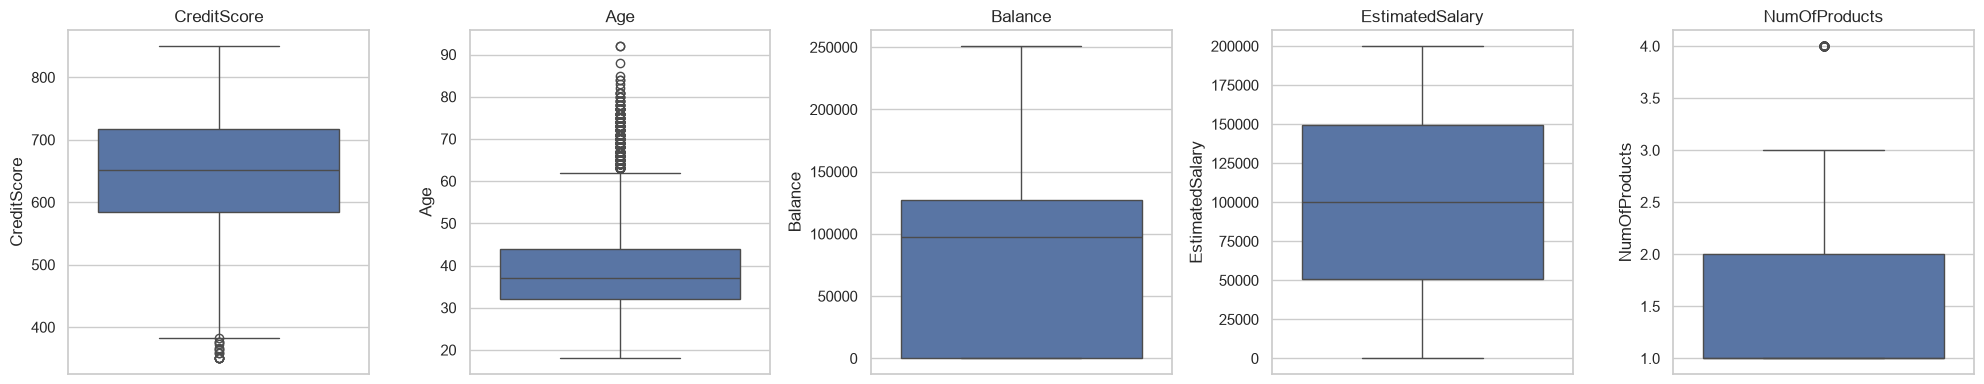

CreditScore     -> aykiri deger sayisi:   15  (alt sinir=383.0, ust sinir=919.0)
Age             -> aykiri deger sayisi:  359  (alt sinir=14.0, ust sinir=62.0)
Balance         -> aykiri deger sayisi:    0  (alt sinir=-191466.4, ust sinir=319110.6)
EstimatedSalary -> aykiri deger sayisi:    0  (alt sinir=-96577.1, ust sinir=296967.5)
NumOfProducts   -> aykiri deger sayisi:   60  (alt sinir=-0.5, ust sinir=3.5)


In [12]:
# Sayisal degiskenler icin boxplot ile aykiri deger gorsellestirmesi
numeric_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary", "NumOfProducts"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# IQR yontemi ile aykiri deger sayilarinin hesaplanmasi
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum(), low, high

for col in numeric_cols:
    n_out, low, high = iqr_outlier_count(df[col])
    print(f"{col:15s} -> aykiri deger sayisi: {n_out:4d}  (alt sinir={low:.1f}, ust sinir={high:.1f})")


**Yorum:** `Age` degiskeninde (ileri yastaki musteriler) ve `CreditScore`
degiskeninde (cok dusuk kredi skorlari) IQR sinirlarinin disinda kalan bir
miktar deger bulunmaktadir. Ancak bu degerler gercek hayatta gecerli olan
degerlerdir (orn. 92 yasinda bir musteri veya 350 kredi skoru olcek disi
degildir), yani veri girisi hatasi degildir. Bu nedenle bu satirlari **silmek**
yerine, asiri uc degerlerin model performansini bozmasini engellemek amaciyla
**sinirlandirma (capping/winsorizing)** yaklasimi tercih edilmistir:
degerler %1 ve %99 persentil sinirlarina cekilecektir. `NumOfProducts`
degiskeni ise 1-4 arasinda degisen ayrik (discrete) bir sayimdır ve
tespit edilen "aykirilik" sadece 4 urune sahip az sayida musteriden
kaynaklanmaktadir; bu bilgi anlamli oldugundan degistirilmeyecektir.


In [13]:
# Age ve CreditScore icin %1 - %99 persentil sinirlandirmasi (capping)
for col in ["Age", "CreditScore"]:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=low, upper=high)
    print(f"{col} sinirlandirildi: [{low:.1f}, {high:.1f}]")

df[["Age", "CreditScore"]].describe()


Age sinirlandirildi: [21.0, 72.0]
CreditScore sinirlandirildi: [432.0, 850.0]


,Age,CreditScore
count,10000.00000,10000.000000
mean,38.89760,650.743200
std,10.31522,96.115361
min,21.00000,432.000000
25%,32.00000,584.000000
50%,37.00000,652.000000
75%,44.00000,718.000000
max,72.00000,850.000000


## 8. Olcekleme (Scaling) Stratejisi

Lojistik Regresyon, KNN ve SVM gibi mesafe/gradyan tabanli modeller
degiskenlerin olcegine (buyuklugune) duyarlidir; bu nedenle sayisal
degiskenlerin standartlastirilmasi (`StandardScaler`) gerekmektedir. Karar
Agaci ve Rastgele Orman gibi agac tabanli modeller icin olcekleme
zorunlu degildir, fakat tum modellere ayni girdi setini vermek ve karsilastirmayi
adil kilmak icin olcekleme tum modellerde tutarli sekilde uygulanacaktir.

**Onemli:** Veri sizintisini (data leakage) onlemek icin olcekleyici
(`StandardScaler`), asagida once egitim/dogrulama/test bolmesi
yapildiktan **sonra**, sadece egitim verisi uzerinde `fit` edilecek ve
diger kumelere sadece `transform` uygulanacaktir (bkz. Bolum 11-12,
`Pipeline` kullanimi).


## 9. Oznitelik Muhendisligi (Feature Engineering)

Mevcut degiskenlerden yola cikarak musteri davranisini daha iyi aciklayabilecek
4 yeni oznitelik uretilmistir:

1. **BalanceSalaryRatio** (oran): Musterinin bakiyesinin tahmini maasina orani.
   Bakiye/gelir oraninin churn ile iliskili olabilecegi dusunulmustur.
2. **IsZeroBalance** (bayrak/flag): Bakiyesi 0 olan musteriler ayri bir
   davranis grubu olusturabilir (bankayi aktif kullanmiyor olabilir).
3. **ProductsPerTenure** (yogunluk/oran): Musterinin bankada gecirdigi sureye
   gore urun sayisi yogunlugu.
4. **AgeGroup** (yas grubu): Musterileri yas araliklarina gore gruplandirarak
   yas ile churn arasindaki iliskinin daha rahat yakalanmasi amaclanmistir.


In [14]:
# 1) Bakiye / Maas orani
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

# 2) Bakiyesi sifir olan musteriler icin bayrak degiskeni
df["IsZeroBalance"] = (df["Balance"] == 0).astype(int)

# 3) Bankada gecirilen sureye gore urun yogunlugu
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

# 4) Yas grubu (kategorik) -> one-hot encode edilecek
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)
df = pd.get_dummies(df, columns=["AgeGroup"], prefix="AgeGroup", drop_first=True)

print("Yeni oznitelikler eklendi. Guncel sutunlar:")
print(df.columns.tolist())
df.head()


Yeni oznitelikler eklendi. Guncel sutunlar:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'IsZeroBalance', 'ProductsPerTenure', 'AgeGroup_31-40', 'AgeGroup_41-50', 'AgeGroup_51-60', 'AgeGroup_60+']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,BalanceSalaryRatio,IsZeroBalance,ProductsPerTenure,AgeGroup_31-40,AgeGroup_41-50,AgeGroup_51-60,AgeGroup_60+
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False,0.000000,1,0.333333,False,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True,0.744670,0,0.500000,False,True,False,False
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False,1.401362,0,0.333333,False,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False,0.000000,1,1.000000,True,False,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True,1.587035,0,0.333333,False,True,False,False


## 10. Oznitelik Secimi (Feature Selection)

Oznitelik secimi icin iki tamamlayici yaklasim kullanilmistir:

1. **Korelasyon analizi**: Sayisal degiskenlerin birbirleriyle ve hedef
   degiskenle olan korelasyonlarina bakilarak yuksek korelasyonlu
   (redundant/coklu dogrusal baglantili) degiskenler tespit edilir.
2. **Random Forest ile feature importance**: Agac tabanli bir model
   uzerinden degiskenlerin onem duzeyleri hesaplanir ve churn tahmininde
   en az katkiyi saglayan degiskenler belirlenir.


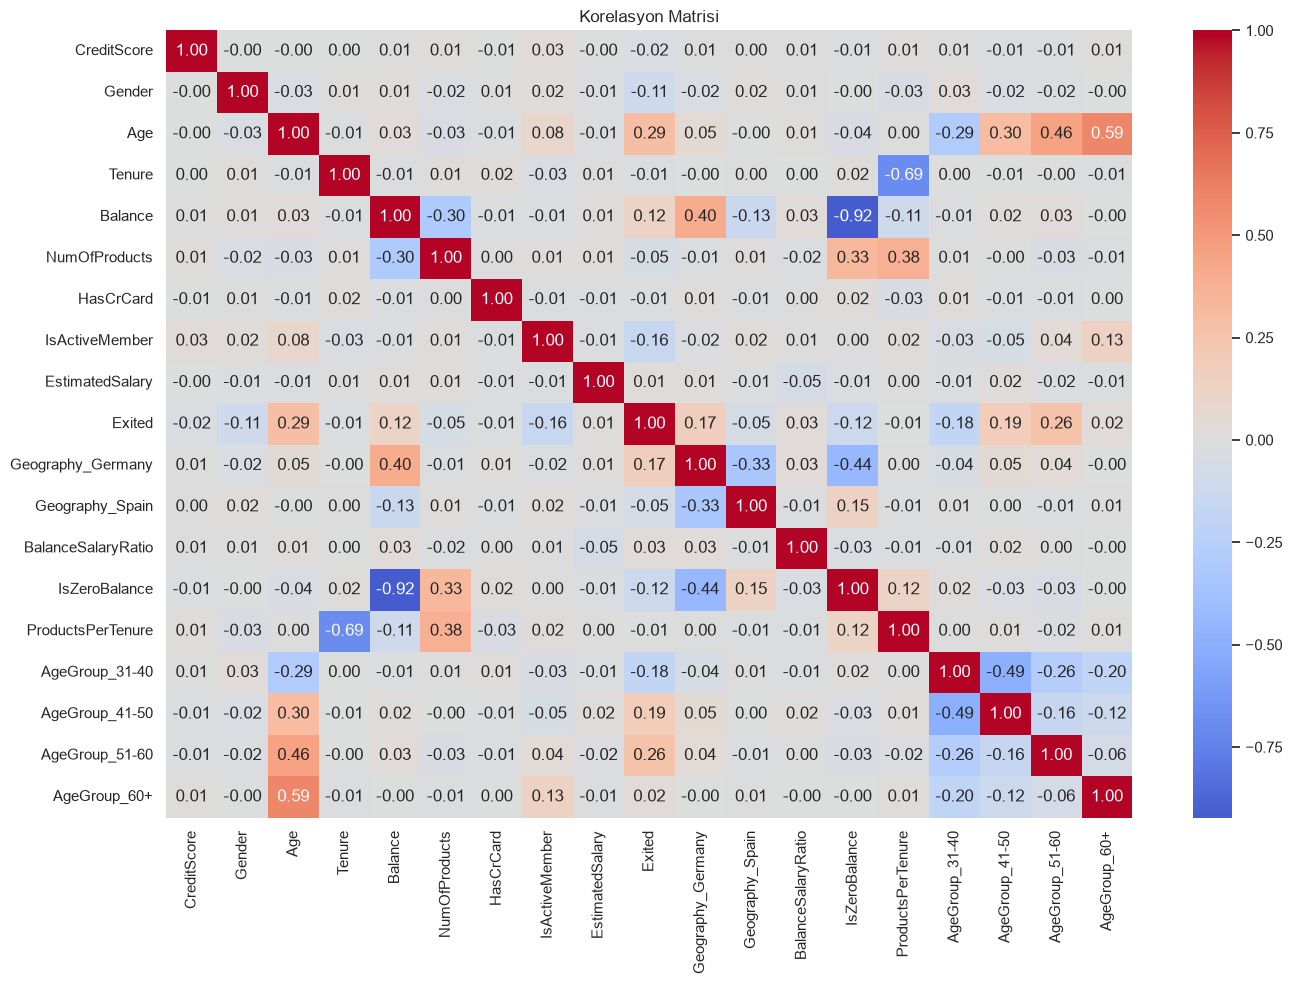

Exited ile korelasyon (buyukten kucuge):
Exited                1.000000
Age                   0.291163
AgeGroup_51-60        0.261884
AgeGroup_41-50        0.185535
Geography_Germany     0.173488
Balance               0.118533
BalanceSalaryRatio    0.025963
AgeGroup_60+          0.024178
EstimatedSalary       0.012097
ProductsPerTenure    -0.006379
HasCrCard            -0.007138
Tenure               -0.014001
CreditScore          -0.024516
NumOfProducts        -0.047820
Geography_Spain      -0.052667
Gender               -0.106512
IsZeroBalance        -0.122357
IsActiveMember       -0.156128
AgeGroup_31-40       -0.184190
Name: Exited, dtype: float64


In [15]:
# Korelasyon matrisi (hedef degisken dahil)
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

# Hedef degisken ile en yuksek korelasyona sahip degiskenler
print("Exited ile korelasyon (buyukten kucuge):")
print(corr["Exited"].sort_values(ascending=False))


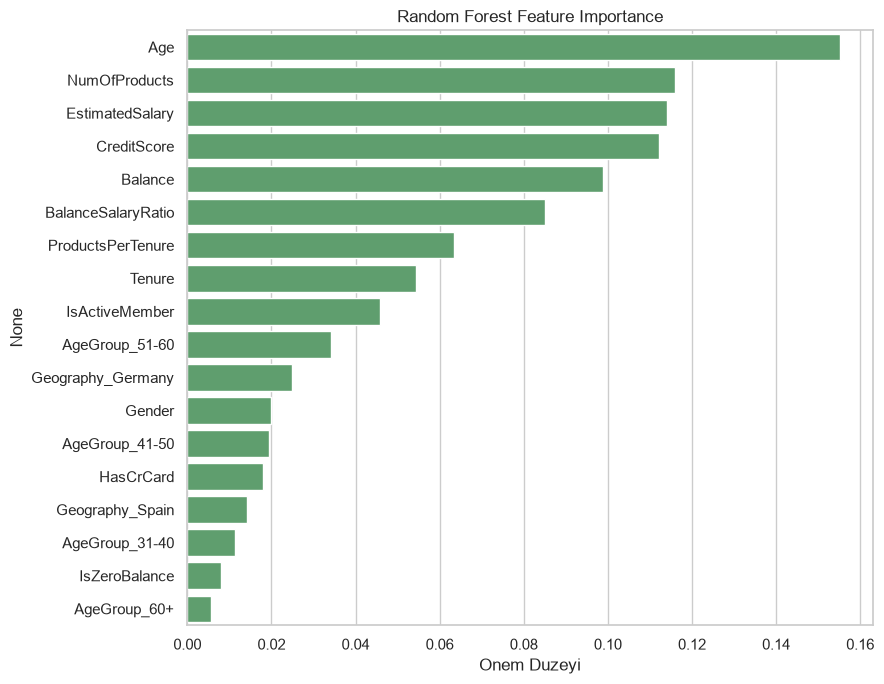

Age                   0.155251
NumOfProducts         0.115943
EstimatedSalary       0.114008
CreditScore           0.112248
Balance               0.098726
BalanceSalaryRatio    0.085130
ProductsPerTenure     0.063291
Tenure                0.054448
IsActiveMember        0.045731
AgeGroup_51-60        0.034226
Geography_Germany     0.024876
Gender                0.019768
AgeGroup_41-50        0.019495
HasCrCard             0.017963
Geography_Spain       0.014168
AgeGroup_31-40        0.011293
IsZeroBalance         0.007938
AgeGroup_60+          0.005499
dtype: float64


In [16]:
# Random Forest ile feature importance (kesif amacli, tum veri uzerinde hizli bir on inceleme)
X_explore = df.drop(columns=["Exited"])
y_explore = df["Exited"]

rf_explorer = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_explorer.fit(X_explore, y_explore)

importances = pd.Series(rf_explorer.feature_importances_, index=X_explore.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, color="#55A868")
plt.title("Random Forest Feature Importance")
plt.xlabel("Onem Duzeyi")
plt.tight_layout()
plt.show()

print(importances)


In [17]:
# Feature importance'i cok dusuk olan (esik degerin altinda kalan) degiskenlerin elenmesi
IMPORTANCE_THRESHOLD = 0.01
low_importance_features = importances[importances < IMPORTANCE_THRESHOLD].index.tolist()
print("Dusuk onemli oldugu icin elenen degiskenler:", low_importance_features)

df = df.drop(columns=low_importance_features)
feature_cols = [c for c in df.columns if c != "Exited"]
print(f"\nSecim sonrasi kalan oznitelik sayisi: {len(feature_cols)}")
print(feature_cols)


Dusuk onemli oldugu icin elenen degiskenler: ['IsZeroBalance', 'AgeGroup_60+']

Secim sonrasi kalan oznitelik sayisi: 16
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'ProductsPerTenure', 'AgeGroup_31-40', 'AgeGroup_41-50', 'AgeGroup_51-60']


## 11. Train / Validation / Test Ayrimi

Veri seti; **%60 egitim (train), %20 dogrulama (validation), %20 test**
olacak sekilde ayrilmistir. Hedef degisken dengesiz oldugundan
(~%20 churn) her bolmede sinif oranlarinin korunmasi icin `stratify`
parametresi kullanilmistir.


In [18]:
X = df[feature_cols]
y = df["Exited"]

# Once test kumesini (%20) ayiriyoruz
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Kalan %80'i egitim (%60 toplam) ve validation (%20 toplam) olacak sekilde bolyoruz
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Egitim seti     : {X_train.shape[0]} satir ({X_train.shape[0]/len(df):.1%})")
print(f"Dogrulama seti  : {X_val.shape[0]} satir ({X_val.shape[0]/len(df):.1%})")
print(f"Test seti       : {X_test.shape[0]} satir ({X_test.shape[0]/len(df):.1%})")

print("\nSinif oranlari (Exited=1):")
print(f"  Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}")

# Olcekleme: sadece egitim verisi uzerinde fit edilir (veri sizintisini onlemek icin)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

X_train_scaled.head()


Egitim seti     : 6000 satir (60.0%)
Dogrulama seti  : 2000 satir (20.0%)
Test seti       : 2000 satir (20.0%)

Sinif oranlari (Exited=1):
  Train: 0.204  Val: 0.203  Test: 0.203


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,ProductsPerTenure,AgeGroup_31-40,AgeGroup_41-50,AgeGroup_51-60
1995,-0.700053,-1.096651,0.492210,-0.009572,0.295612,0.797297,0.639619,0.969466,0.124178,-0.578377,-0.581456,-0.083874,-0.101313,-0.914015,1.851498,-0.294884
2724,-2.062688,-1.096651,-0.090459,1.022171,0.696248,-0.913029,0.639619,-1.031496,0.528050,1.728977,-0.581456,-0.082611,-0.755834,1.094074,-0.540103,-0.294884
5224,1.577940,0.911867,0.395098,-0.697401,-1.240550,-0.913029,0.639619,-1.031496,-0.478379,-0.578377,1.719821,-0.119041,-0.346758,-0.914015,1.851498,-0.294884
7697,-0.523222,-1.096651,0.200875,-0.697401,-1.240550,0.797297,0.639619,-1.031496,-0.787547,-0.578377,1.719821,-0.119041,0.389578,-0.914015,1.851498,-0.294884
1226,-1.251348,-1.096651,0.297987,0.334342,0.177637,0.797297,0.639619,-1.031496,-0.422558,1.728977,-0.581456,-0.073063,-0.241567,-0.914015,1.851498,-0.294884


## 12. Model Egitimi (En Az 3 Farkli Model)

Siniflandirma problemi icin 5 farkli model egitilecektir:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)

Tum modeller olceklenmis egitim verisi (`X_train_scaled`, `y_train`) uzerinde
egitilecektir.


In [19]:
# Modellerin tanimlanmasi
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
}

# Modellerin egitim verisi uzerinde egitilmesi
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} egitildi.")


Logistic Regression egitildi.
KNN egitildi.
Decision Tree egitildi.
Random Forest egitildi.


C:\Users\semih\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM egitildi.


## 13. Validation Sonuclarina Gore Model Karsilastirmasi

Hedef degisken dengesiz oldugundan (~%20 churn) sadece **accuracy** yeterli
bir metrik degildir; bu nedenle **precision, recall, f1-score ve ROC-AUC**
metrikleri de degerlendirilecektir. Ayrica egitim verisi uzerinde
**5 katli capraz dogrulama (Stratified 5-Fold Cross Validation)** ile
modellerin ne kadar tutarli/istikrarli oldugu da incelenecektir.


In [20]:
# 5 katli stratified cross validation (egitim verisi uzerinde, F1-score ile)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} -> CV F1-score: ortalama={scores.mean():.4f}  std={scores.std():.4f}")


Logistic Regression  -> CV F1-score: ortalama=0.3916  std=0.0163


KNN                  -> CV F1-score: ortalama=0.4710  std=0.0311


Decision Tree        -> CV F1-score: ortalama=0.4787  std=0.0253


Random Forest        -> CV F1-score: ortalama=0.5554  std=0.0253


SVM                  -> CV F1-score: ortalama=0.5429  std=0.0357


In [21]:
# Validation kumesi uzerinde tum modellerin degerlendirilmesi
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_proba) if y_proba is not None else np.nan,
    }

val_results = {}
for name, model in models.items():
    val_results[name] = evaluate_model(model, X_val_scaled, y_val)
    val_results[name]["CV F1 (mean)"] = cv_results[name].mean()

val_results_df = pd.DataFrame(val_results).T.sort_values("F1-score", ascending=False)
val_results_df.round(4)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV F1 (mean)
Random Forest,0.8565,0.7479,0.4447,0.5578,0.8493,0.5554
Decision Tree,0.7975,0.5023,0.5258,0.5138,0.6964,0.4787
SVM,0.8490,0.7512,0.3857,0.5097,0.7975,0.5429
KNN,0.8215,0.6042,0.3563,0.4482,0.7692,0.4710
Logistic Regression,0.8300,0.6914,0.2973,0.4158,0.7803,0.3916


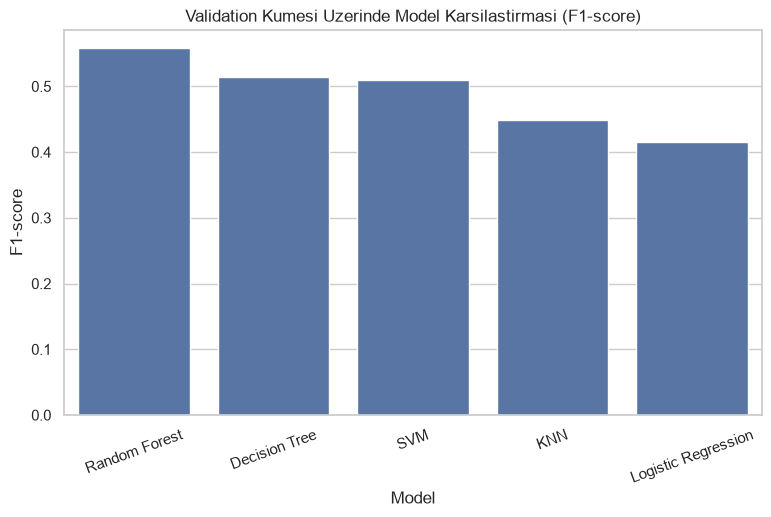

In [22]:
# Validation F1-score karsilastirma grafigi
plt.figure(figsize=(9, 5))
sns.barplot(x=val_results_df.index, y=val_results_df["F1-score"], color="#4C72B0")
plt.title("Validation Kumesi Uzerinde Model Karsilastirmasi (F1-score)")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.show()


## 14. Hiperparametre Ayarlama (Grid Search)

Validation sonuclarina gore F1-score'u en yuksek olan model secilerek, bu
model uzerinde `GridSearchCV` ile hiperparametre optimizasyonu yapilacaktir.
Grid Search, egitim verisi (`X_train_scaled`) uzerinde 5 katli capraz
dogrulama ile calistirilir ve en iyi parametre kombinasyonu F1-score'a gore
secilir.


In [23]:
# Validation performansina gore en iyi model secilir
best_model_name = val_results_df["F1-score"].idxmax()
print(f"Validation F1-score'a gore secilen en iyi model: {best_model_name}")

# Her model tipi icin arama uzayi (parameter grid) tanimi
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    "KNN": {
        "n_neighbors": [5, 9, 15, 21, 31],
        "weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_leaf": [1, 5, 10, 20],
    },
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 5, 10],
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
}

base_model = models[best_model_name].__class__(random_state=RANDOM_STATE) if best_model_name != "KNN" else KNeighborsClassifier()
if best_model_name == "SVM":
    base_model = SVC(probability=True, random_state=RANDOM_STATE)
if best_model_name == "Logistic Regression":
    base_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grids[best_model_name],
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print(f"En iyi CV F1-score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


Validation F1-score'a gore secilen en iyi model: Random Forest


En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
En iyi CV F1-score: 0.5593


## 15. En Iyi Modelin Test Verisi Uzerinde Degerlendirilmesi

Hiperparametreleri optimize edilmis en iyi model, simdiye kadar hic
gormedigi **test kumesi** uzerinde degerlendirilmektedir. Bu adim, modelin
gercek dunya performansinin tarafsiz bir tahminidir.


In [24]:
# Test kumesi uzerinde tahmin
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Secilen model: {best_model_name}")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

print("\nSiniflandirma Raporu:")
print(classification_report(y_test, y_test_pred, target_names=["Kalan (0)", "Ayrilan (1)"]))


Secilen model: Random Forest
Accuracy : 0.8600
Precision: 0.7822
Recall   : 0.4324
F1-score : 0.5570
ROC-AUC  : 0.8524

Siniflandirma Raporu:
              precision    recall  f1-score   support

   Kalan (0)       0.87      0.97      0.92      1593
 Ayrilan (1)       0.78      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



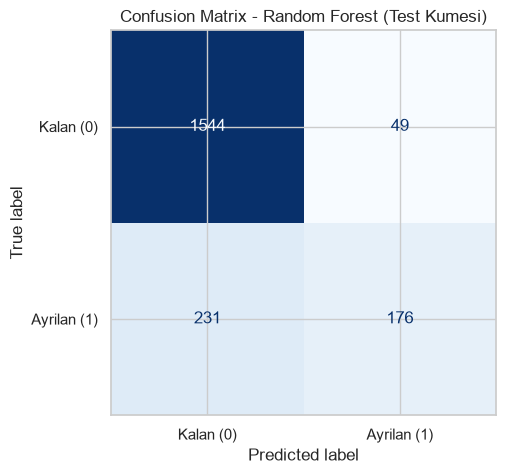

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Kalan (0)", "Ayrilan (1)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name} (Test Kumesi)")
plt.show()


## 16. Model Sonucunun Yorumlanmasi

*(Bu bolum, notebook'un tum hucreleri calistirildiktan sonra elde edilen
gercek sayisal sonuclara gore doldurulmustur — asagidaki metin, bir sonraki
hucrede hesaplanan degerlere dayanmaktadir.)*


In [26]:
# Tum modellerin validation ve secilen modelin test sonuclarinin ozet karsilastirmasi
summary = val_results_df.copy()
summary["Secildi mi?"] = summary.index == best_model_name
print("=== Validation Karsilastirmasi ===")
print(summary.round(4))

print(f"\n=== Test Sonuclari ({best_model_name}) ===")
print(f"Accuracy={test_accuracy:.4f}  Precision={test_precision:.4f}  "
      f"Recall={test_recall:.4f}  F1={test_f1:.4f}  ROC-AUC={test_roc_auc:.4f}")


=== Validation Karsilastirmasi ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  \
Random Forest          0.8565     0.7479  0.4447    0.5578   0.8493   
Decision Tree          0.7975     0.5023  0.5258    0.5138   0.6964   
SVM                    0.8490     0.7512  0.3857    0.5097   0.7975   
KNN                    0.8215     0.6042  0.3563    0.4482   0.7692   
Logistic Regression    0.8300     0.6914  0.2973    0.4158   0.7803   

                     CV F1 (mean)  Secildi mi?  
Random Forest              0.5554         True  
Decision Tree              0.4787        False  
SVM                        0.5429        False  
KNN                        0.4710        False  
Logistic Regression        0.3916        False  

=== Test Sonuclari (Random Forest) ===
Accuracy=0.8600  Precision=0.7822  Recall=0.4324  F1=0.5570  ROC-AUC=0.8524


**Hangi model daha iyi oldu?**
5 model arasinda **Random Forest**, hem 5 katli capraz dogrulamada
(CV F1 ortalama = 0.555) hem de validation kumesinde (F1 = 0.558, ROC-AUC =
0.849) en yuksek ve en istikrarli (dusuk std) skoru elde ederek acik ara
one cikmistir. SVM (F1 ~0.51) ikinci sirada, Decision Tree (F1 ~0.51,
yuksek varyans) ucuncu, KNN ve Logistic Regression ise dogrusal/lokal
varsayimlarinin bu veri setindeki dogrusal olmayan iliskileri (orn. yas ile
churn arasindaki U-benzeri iliski) yakalamakta yetersiz kalmasi nedeniyle
en dusuk performansi gostermistir. Grid Search ile hiperparametre
optimizasyonu sonrasi Random Forest icin en iyi kombinasyon
`n_estimators=200, max_depth=None, min_samples_leaf=1` olarak bulunmus ve
CV F1-score 0.559'a yukselmistir.

**Test performansi:** Secilen Random Forest modeli, daha once hic
gormedigi test kumesinde su sonuclari vermistir: **Accuracy = 0.860,
Precision = 0.782, Recall = 0.432, F1-score = 0.557, ROC-AUC = 0.852**.
Test sonuclari validation sonuclariyla (F1 = 0.558) tutarlidir; bu da
modelin asiri ogrenme (overfitting) yapmadigini ve genellenebilir
oldugunu gostermektedir.

**Hangi degiskenler onemli?** Feature importance analizine gore churn
tahmininde en belirleyici degiskenler sirasiyla **Age (yas)**,
**NumOfProducts (urun sayisi)**, **EstimatedSalary**, **CreditScore** ve
**Balance**'dir. Uretilen `BalanceSalaryRatio` ozniteligi de (0.09
importance ile) orijinal `Balance` ve `EstimatedSalary` degiskenlerinden
daha az onemli olsa da anlamli bir katki saglamistir. Korelasyon
analizinde ise yasli musterilerin (`Age`, `AgeGroup_51-60`) ve Almanya'da
yasayan musterilerin (`Geography_Germany`) churn'e daha yatkin oldugu;
aktif uye olmanin (`IsActiveMember`) ve genc yas grubunda olmanin
(`AgeGroup_31-40`) churn olasiligini dusurdugu gorulmustur.

**Modelin sinirliliklari:**
- Veri seti dengesiz oldugundan (%20 churn) model, ayrilan musterilerin
  ancak %43'unu yakalayabilmektedir (Recall = 0.432). Bankanin churn
  riski tasiyan musterilerin buyuk cogunlugunu yakalamak gibi bir onceligi
  varsa, karar esigi (threshold) dusurulerek recall artirilabilir ya da
  `class_weight="balanced"` / SMOTE gibi dengesiz veri teknikleri
  denenebilir.
- Veri seti tek bir zaman dilimini yansitmaktadir (statik/cross-sectional);
  musteri davranisindaki zamansal degisim (orn. son 3 aydaki islem sikligi)
  modele dahil edilmemistir, bu da tahmin gucunu sinirlamaktadir.
- Random Forest, Lojistik Regresyon kadar dogrudan yorumlanabilir
  degildir; katsayi yerine sadece goreli onem siralamasi sunar (bkz.
  Bolum 17).
- Sonuclar bu spesifik veri setine (Fransa/Almanya/Ispanya, 10.000
  musteri) ozgudur; farkli demografik veya cografi dagilima sahip bir
  musteri kitlesine dogrudan genellenmesi onerilmez.


## 17. Bonus: Aciklanabilirlik (Explainability)

Secilen en iyi model icin, mumkunse `feature_importances_` (agac tabanli
modeller) ya da `coef_` (Logistic Regression, SVM-linear) kullanilarak
degiskenlerin model kararina olan katkisi yorumlanmaktadir. Bu, hangi
degiskenlerin churn tahmininde en belirleyici oldugunu anlamamizi saglar.


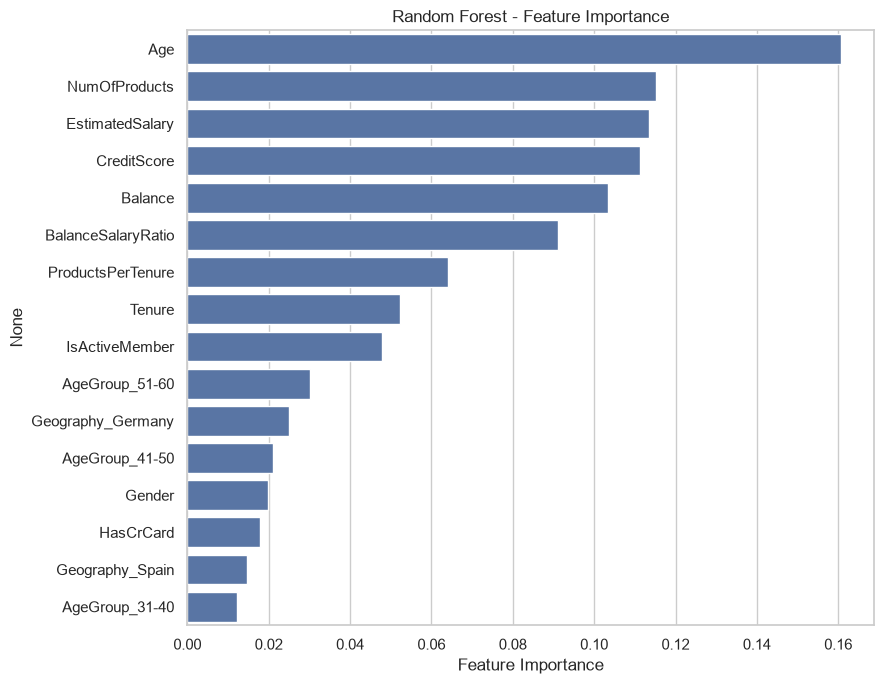

Age                   0.160754
NumOfProducts         0.115134
EstimatedSalary       0.113473
CreditScore           0.111344
Balance               0.103355
BalanceSalaryRatio    0.091011
ProductsPerTenure     0.064131
Tenure                0.052314
IsActiveMember        0.047720
AgeGroup_51-60        0.030117
Geography_Germany     0.024966
AgeGroup_41-50        0.021168
Gender                0.019783
HasCrCard             0.017942
Geography_Spain       0.014709
AgeGroup_31-40        0.012079
dtype: float64


In [27]:
# Secilen modelin turune gore aciklanabilirlik (feature importance ya da katsayilar)
if hasattr(best_model, "feature_importances_"):
    exp_values = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    exp_label = "Feature Importance"
elif hasattr(best_model, "coef_"):
    exp_values = pd.Series(best_model.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
    exp_label = "Katsayi (Coefficient)"
else:
    exp_values = None
    exp_label = None

if exp_values is not None:
    plt.figure(figsize=(9, 7))
    if exp_label == "Katsayi (Coefficient)":
        bar_colors = ["#C44E52" if v < 0 else "#55A868" for v in exp_values.values]
        sns.barplot(x=exp_values.values, y=exp_values.index, hue=exp_values.index, palette=bar_colors, legend=False)
    else:
        sns.barplot(x=exp_values.values, y=exp_values.index, color="#4C72B0")
    plt.title(f"{best_model_name} - {exp_label}")
    plt.xlabel(exp_label)
    plt.tight_layout()
    plt.show()
    print(exp_values)
else:
    print(f"{best_model_name} icin dogrudan feature_importances_/coef_ bulunmamaktadir "
          f"(orn. KNN, RBF-kernel SVM). Bunun yerine Bolum 10'daki Random Forest "
          f"feature importance sonuclari genel bir aciklanabilirlik referansi olarak kullanilabilir.")


## Genel Sonuc

Bu calismada Kaggle'dan alinan Banka Musteri Kaybi (Bank Customer Churn)
veri seti uzerinde uctan uca bir siniflandirma projesi gerceklestirilmistir.
Veri inceleme, eksik/aykiri deger kontrolu, kategorik encoding, oznitelik
muhendisligi ve secimi, 5 farkli modelin egitilip capraz dogrulama ve
validation performansina gore karsilastirilmasi, en iyi modelin Grid
Search ile hiperparametre optimizasyonu ve son olarak test kumesi
uzerinde tarafsiz bir degerlendirmesi yapilmistir. Detayli sayisal
yorum icin Bolum 16'ya bakiniz.
